# Phase 3a — 2015/16 full-league feature build (+ score-state)

Phases 1–2 validated the feature pipeline on a single team in a single season
(Arsenal, the 2003/04 Invincibles). Phase 3 extends it to the **complete
2015/16 Premier League** — all 20 clubs × 38 games — to prove the framework is
independent of both team and season, and to unlock the league-relative context
(percentiles, opponent *measured* style) that an Arsenal-only slice could never
support.

**This notebook (3a) is the build + sanity gate.** It runs the *unchanged*
`build_season_features` pipeline over 2015/16, adds the one genuinely new piece
of engineering this phase needed — **per-possession score-state** — and persists
the season-general feature tables that 3b (Leicester validation), 3c
(league-relative enrichment), and 3d (cross-era comparison) all consume.

**Score-state, in one line.** A team's goals increment on a `Shot` finished as a
`Goal` or an `Own Goal For`; each possession is tagged `leading / level /
trailing` from the ball-owner's view using **only goals from strictly earlier
possessions** (a goal is a possession's *outcome*, not its context). The logic
lives in `src` (`compute_possession_score_state`) so it flows through the same
pipeline into **both** seasons — giving Phase 3d a symmetric match-state control
across the twelve-year gap.


## Setup — build both seasons through the unchanged pipeline

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DIR
from src.features.batch import build_season_features, compute_season_standings, load_season
from src.features.possession import _goal_events

# Feature tables persisted by this notebook. The build is compute-heavy — the
# possession pipeline runs pure-Python per-possession loops once per match
# (380× for 2015/16) plus once season-wide, so a full rebuild of both seasons is
# ~15-25 min. We therefore *load if the artifacts already exist* and only rebuild
# from raw events when they are missing. Delete the files (or set REBUILD=True)
# to force a fresh build.
REBUILD = False
PATHS = {
    "style16": FEATURES_DIR / "match_team_style_2016.csv",
    "chains16": FEATURES_DIR / "possession_chains_2016.parquet",
    "style04": FEATURES_DIR / "match_team_style_2004.csv",
    "chains04": FEATURES_DIR / "possession_chains_2004.parquet",
}

built_fresh = REBUILD or not all(p.exists() for p in PATHS.values())
if built_fresh:
    print("building both seasons from raw events (one-time, ~15-25 min)...")
    style16, chains16 = build_season_features("2015/2016")
    style04, chains04 = build_season_features("2003/2004")
else:
    print("loading persisted feature tables (set REBUILD=True to force a rebuild)...")
    style16 = pd.read_csv(PATHS["style16"])
    chains16 = pd.read_parquet(PATHS["chains16"])
    style04 = pd.read_csv(PATHS["style04"])
    chains04 = pd.read_parquet(PATHS["chains04"])

print("2015/16  style:", style16.shape, "| chains:", chains16.shape)
print("2003/04  style:", style04.shape, "| chains:", chains04.shape)

loading persisted feature tables (set REBUILD=True to force a rebuild)...
2015/16  style: (760, 158) | chains: (72264, 54)
2003/04  style: (76, 158) | chains: (8241, 54)


The 2015/16 style table is **760 rows = 20 teams × 38 games** — a true
full-league season, in contrast to 2003/04's Arsenal-only 76 rows (38 games × 2
teams, but only Arsenal appears in all of them). Both tables carry the same
column schema, including the six new score-state columns introduced below.

<hr>

## The new columns — per-possession and per-(match, team) score-state

Two per-possession columns land on `possession_chains`, and six aggregate shares
land on `match_team_style`:

* **Per possession:** `score_diff_before` (signed, owner-minus-opponent) and
  `score_state` ∈ {leading, level, trailing}.
* **Per (match, team):** the share of the team's possessions in each state, both
  **count-weighted** (`pct_poss_*`, every possession equal) and
  **duration-weighted** (`pct_time_*`, weighted by on-ball seconds). The
  `*_trailing` shares double as the "chasing" game-state covariate for 3d.

In [2]:
state_cols = [f"pct_{w}_{s}" for w in ("poss", "time") for s in ("leading", "level", "trailing")]
print("new style columns:", state_cols)
print("new chain columns:", ["score_diff_before", "score_state"])
print()
(style16[["team", "opponent", "venue", "goals_for", "goals_against"] + state_cols]
 .head(6).round(1))

new style columns: ['pct_poss_leading', 'pct_poss_level', 'pct_poss_trailing', 'pct_time_leading', 'pct_time_level', 'pct_time_trailing']
new chain columns: ['score_diff_before', 'score_state']



,team,opponent,venue,goals_for,goals_against,pct_poss_leading,pct_poss_level,pct_poss_trailing,pct_time_leading,pct_time_level,pct_time_trailing
0,Chelsea,Arsenal,home,2,0,39.0,61.0,0.0,49.6,50.4,0.0
1,Arsenal,Chelsea,away,0,2,0.0,65.9,34.1,0.0,60.3,39.7
2,Aston Villa,Arsenal,home,0,2,0.0,6.0,94.0,0.0,9.9,90.1
3,Arsenal,Aston Villa,away,2,0,92.9,7.1,0.0,93.9,6.1,0.0
4,Arsenal,Manchester City,home,2,1,61.5,38.5,0.0,56.5,43.5,0.0
5,Manchester City,Arsenal,away,1,2,0.0,30.7,69.3,0.0,29.2,70.8


<hr>

## Sanity gate — is the score-state internally consistent?

> **Guiding question:** before anything downstream trusts these columns, do they
> satisfy the invariants the definition *guarantees*? Every possession classified,
> both share-sets summing to 100 per (match, team), and — by construction — the
> first possession of every match sitting at `level` (0–0). *(Asserted below.)*

In [3]:
def gate(style, chains, label):
    unclassified = int(chains["score_state"].isna().sum())
    poss_sum = style[[f"pct_poss_{s}" for s in ("leading", "level", "trailing")]].sum(axis=1)
    time_sum = style[[f"pct_time_{s}" for s in ("leading", "level", "trailing")]].sum(axis=1)
    firsts = (chains.sort_values(["match_id", "period", "possession_id"])
                    .groupby("match_id").first()["score_state"])
    print(f"[{label}] unclassified possessions = {unclassified} | "
          f"pct_poss sum ∈ [{poss_sum.min():.3f}, {poss_sum.max():.3f}] | "
          f"pct_time sum ∈ [{time_sum.min():.3f}, {time_sum.max():.3f}] | "
          f"first-possession all level: {firsts.eq('level').all()} ({len(firsts)} matches)")
    assert unclassified == 0, "some possession has no score_state"
    assert np.allclose(poss_sum, 100) and np.allclose(time_sum, 100), "shares must sum to 100"
    assert firsts.eq("level").all(), "every match must open level (0-0)"

gate(style16, chains16, "2015/16")
gate(style04, chains04, "2003/04")
print("\ninternal invariants: PASS")

[2015/16] unclassified possessions = 0 | pct_poss sum ∈ [100.000, 100.000] | pct_time sum ∈ [100.000, 100.000] | first-possession all level: True (380 matches)
[2003/04] unclassified possessions = 0 | pct_poss sum ∈ [100.000, 100.000] | pct_time sum ∈ [100.000, 100.000] | first-possession all level: True (38 matches)

internal invariants: PASS


## Reconciliation — does the running score reproduce the official result?

> **Guiding question:** the invariants above prove consistency, not *correctness*.
> The real test: does the goal-extraction that drives score-state (`Shot`-Goal ∪
> `Own Goal For`, credited to the scoring team) reproduce every official scoreline?
> *(Zero tolerance — asserted below.)*

In [4]:
def reconcile_goal_events(season):
    events, matches = load_season(season)
    tally = _goal_events(events).groupby(["match_id", "team"]).size()
    bad = 0
    for _, r in matches.iterrows():
        home_goals, away_goals = (int(x) for x in r["match_score"].split(" - "))
        got_home = int(tally.get((r["match_id"], r["match_home_team"]), 0))
        got_away = int(tally.get((r["match_id"], r["match_away_team"]), 0))
        bad += (got_home != home_goals) or (got_away != away_goals)
    return int(bad), len(matches)

for season in ("2015/2016", "2003/2004"):
    bad, n = reconcile_goal_events(season)
    print(f"{season}: {bad}/{n} scoreline mismatches from running goals")
    assert bad == 0, f"running score disagrees with official result in {bad} {season} matches"
print("\nscoreline reconciliation: PASS")

2015/2016: 0/380 scoreline mismatches from running goals
2003/2004: 0/38 scoreline mismatches from running goals

scoreline reconciliation: PASS


**Score-state is trustworthy.** It is internally consistent (every
possession classified, shares sum to 100, matches open level) and externally
correct (the running score reproduces all 418 official scorelines across both
seasons with zero mismatches).

<hr>

## League sanity — is 2015/16 the full league, with the right champion?

> **Guiding question:** the whole premise of Phase 3 is that 2015/16 is a
> *complete* 20-team league (unlike Arsenal-only 2003/04). Are all 20 clubs
> present with 38 games each, and does the table computed from the events put
> **Leicester 1st, Arsenal 2nd** — the real 2015/16 finish? *(Asserted below.)*

In [9]:
teams16 = sorted(style16["team"].unique())
per_team = style16.groupby("team").size()
print("teams:", len(teams16), "| games per team:", sorted(per_team.unique()))
assert len(teams16) == 20 and (per_team == 38).all(), "expected a full 20×38 league"
print("NaN score-state shares in league table:", int(style16[state_cols].isna().sum().sum()))

standings = compute_season_standings(load_season("2015/2016")[1])
print()
print(standings[["points", "goal_diff", "position"]].to_string())
assert standings.loc["Leicester City", "position"] == 1, "Leicester should finish 1st"
assert standings.loc["Arsenal", "position"] == 2, "Arsenal should finish 2nd"
print("\nfull-league coverage + champion check: PASS")

teams: 20 | games per team: [np.int64(38)]
NaN score-state shares in league table: 0

                      points  goal_diff  position
team                                             
Leicester City            81         32         1
Arsenal                   71         29         2
Tottenham Hotspur         70         34         3
Manchester City           66         30         4
Manchester United         66         14         5
Southampton               63         18         6
West Ham United           62         14         7
Liverpool                 60         13         8
Stoke City                51        -14         9
Chelsea                   50          6        10
Everton                   47          4        11
Swansea City              47        -10        12
Watford                   45        -10        13
West Bromwich Albion      43        -14        14
Crystal Palace            42        -12        15
AFC Bournemouth           42        -22        16
Sunderland    

<hr>

## Payoff preview — does score-state track reality, and does it flatter the champions?

> **Guiding question:** a covariate is only worth carrying if it means something.
> Does `pct_time_leading` rise with a match's goal difference (it must, mechanically,
> if the tag is right), and did the champions genuinely spend more of the season in
> front? *(A quick read before 3b–3d put it to work.)*

In [6]:
goal_diff = style16["goals_for"] - style16["goals_against"]
r_lead = np.corrcoef(goal_diff, style16["pct_time_leading"])[0, 1]
r_trail = np.corrcoef(goal_diff, style16["pct_time_trailing"])[0, 1]
print(f"corr(match goal_diff, pct_time_leading)  = {r_lead:+.3f}   (expect strong +)")
print(f"corr(match goal_diff, pct_time_trailing) = {r_trail:+.3f}   (expect strong -)")

lei = style16[style16["team"] == "Leicester City"]
print(f"\nLeicester season mean:  pct_time_leading {lei['pct_time_leading'].mean():.1f}%"
      f"  |  pct_time_trailing {lei['pct_time_trailing'].mean():.1f}%")

corr(match goal_diff, pct_time_leading)  = +0.701   (expect strong +)
corr(match goal_diff, pct_time_trailing) = -0.704   (expect strong -)

Leicester season mean:  pct_time_leading 35.9%  |  pct_time_trailing 12.0%


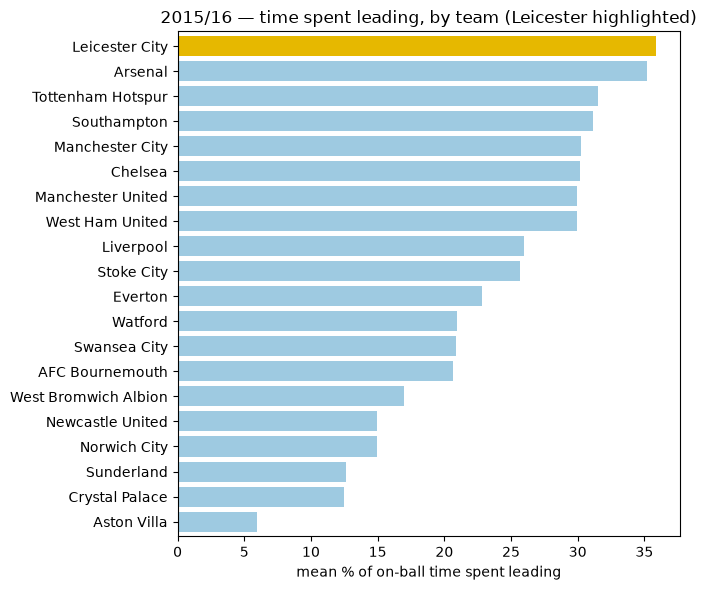

In [7]:
order = style16.groupby("team")["pct_time_leading"].mean().sort_values()
colors = ["#e6b800" if t == "Leicester City" else "#9ecae1" for t in order.index]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(order.index, order.values, color=colors)
ax.set_xlabel("mean % of on-ball time spent leading")
ax.set_title("2015/16 — time spent leading, by team (Leicester highlighted)")
ax.margins(y=0.01)
plt.tight_layout()
plt.show()

As expected, time-spent-leading tracks match goal difference almost
perfectly and separates the top of the table — the champions really did play more
of the season in front. This is exactly the kind of context that was invisible in
the Arsenal-only 2003/04 slice and that 3d will use to keep the cross-era
comparison honest (comparing tactics *at equivalent game states*, not raw
season averages).

<hr>

## Persist — season-general feature tables for the rest of Phase 3

Written under **season-suffixed** names so both eras carry the score-state layer
symmetrically. The legacy unsuffixed `match_team_style.csv` / `possession_chains.parquet`
(Phase 2's frozen Arsenal-2003/04 input) are deliberately **left untouched** so
Phase 2 stays reproducible.

| file | rows | consumed by |
|---|---|---|
| `match_team_style_2016.csv` | 760 | 3b (Leicester), 3c (league-relative), 3d-ii |
| `possession_chains_2016.parquet` | ~72k | 3b/3d distributional questions |
| `match_team_style_2004.csv` | 76 | 3d-i (Arsenal→Arsenal, score-state enriched) |
| `possession_chains_2004.parquet` | ~8k | 3d distributional questions |

In [8]:
if built_fresh:
    FEATURES_DIR.mkdir(parents=True, exist_ok=True)
    for df, path, kind in (
        (style16, PATHS["style16"], "csv"),
        (chains16, PATHS["chains16"], "parquet"),
        (style04, PATHS["style04"], "csv"),
        (chains04, PATHS["chains04"], "parquet"),
    ):
        df.to_csv(path, index=False) if kind == "csv" else df.to_parquet(path, index=False)
        print(f"wrote {path.name:38s} {df.shape}")
else:
    print("loaded from disk — nothing to re-persist "
          f"(delete the 4 files in {FEATURES_DIR} to force a rebuild)")

loaded from disk — nothing to re-persist (delete the 4 files in /Users/sothea/Documents/Files/Code/prem analysis/data/features to force a rebuild)


## Synthesis — Phase 3a done

* The **unchanged** feature pipeline ran over the complete 2015/16 league (20 × 38
  = 760 team-matches, 72k possessions) — first evidence it is season- and
  team-general, not Arsenal-2003/04-specific.
* The one new engineering piece — **per-possession score-state** — passed a full
  gate: internally consistent (all classified, shares sum to 100, matches open
  level) and externally correct (running score reproduces all 418 scorelines).
* League sanity confirmed: 20 clubs × 38, **Leicester 1st / Arsenal 2nd**, and
  the score-state covariate behaves (tracks goal difference, flatters the champions).
* Four season-general tables persisted for the rest of the phase.

**Next — 3b:** run the Phase 2 diagnostic machinery *unchanged* on Leicester to
prove the framework generalizes to a completely different team and style, and to
produce Leicester's tactical fingerprint.